# Relative Aircraft Projection Walkthrough

This notebook is a technical walkthrough of the geometry implemented in
`geometric_safety.relevant_aircraft`.

It uses a few private helpers to expose intermediate objects. Production code should
call:

- `catch_up_projection_interval`
- `catch_up_projection_interval_with_turns`

The notebook has two parts:

1. the fixed-heading solver
2. the turn-aware solver

The aim is to make the implemented method readable from the notebook itself, rather
than only from the production Python.

In [ ]:
import math
from typing import TypedDict

from matplotlib.axes import Axes
from matplotlib.patches import Circle
import matplotlib.pyplot as plt
import numpy as np

from geometric_safety.relevant_aircraft import (
    _interval_distance_lower_bound,
    _interval_local_lipschitz_mps,
    _min_distance_to_relative_hull_at_time,
    _relative_position_hull_at_time,
    _turn_displacement_basis,
    catch_up_projection_interval,
    catch_up_projection_interval_with_turns,
    compute_relative_velocity_hull,
)
from geometric_safety.util import (
    DEG_TO_RAD,
    KT_TO_MPS,
    NMI_TO_M,
    RAD_TO_DEG,
    _closest_point_on_convex_polygon,
    _small_convex_hull,
    heading_to_unit_vector,
    latlon_to_local_xy,
)

np.set_printoptions(precision=3, suppress=True)
# The notebook uses the mean Earth radius for its local helpers, distinct from the
# WGS-84 equatorial radius used by the production solver.
EARTH_RADIUS_IN_METERS = 6_371_000.0


def close_polygon(poly: np.ndarray) -> np.ndarray:
    return poly if poly.shape[0] == 0 else np.vstack([poly, poly[0]])


def style_axes(ax: Axes, title: str, xlabel: str = "East (m)", ylabel: str = "North (m)", equal: bool = True) -> None:
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if equal:
        ax.set_aspect("equal", "box")
    ax.grid(True, alpha=0.25)


def speed_bounds_mps(speed_kt: float, speed_diff_kt: float) -> tuple[float, float]:
    return max(speed_kt - speed_diff_kt, 0.0) * KT_TO_MPS, (speed_kt + speed_diff_kt) * KT_TO_MPS


def local_xy_to_latlon(east_m: float, north_m: float, ref_lat: float, ref_lon: float) -> tuple[float, float]:
    ref_lat_rad = ref_lat * DEG_TO_RAD
    lat = ref_lat + (north_m / EARTH_RADIUS_IN_METERS) * RAD_TO_DEG
    lon = ref_lon + (east_m / (EARTH_RADIUS_IN_METERS * math.cos(ref_lat_rad))) * RAD_TO_DEG
    return lat, lon


def signed_heading_diff_deg(start_deg: float, end_deg: float) -> float:
    return ((end_deg - start_deg + 180.0) % 360.0) - 180.0


def turn_duration_s(heading0_deg: float, target_heading_deg: float, turn_rate_deg_sec: float) -> float:
    if abs(turn_rate_deg_sec) <= 1e-12:
        return 0.0
    return abs(signed_heading_diff_deg(heading0_deg, target_heading_deg)) / abs(turn_rate_deg_sec)


def sample_trajectory_xy(
    start_xy: np.ndarray,
    heading0_deg: float,
    target_heading_deg: float,
    speed_mps: float,
    turn_rate_deg_sec: float,
    times_s: np.ndarray,
) -> np.ndarray:
    xy = np.empty((times_s.shape[0], 2), dtype=np.float64)
    for idx, t_s in enumerate(times_s):
        xy[idx] = start_xy + speed_mps * _turn_displacement_basis(
            heading0_deg, target_heading_deg, turn_rate_deg_sec, float(t_s)
        )
    return xy


def trajectory_point_xy(
    start_xy: np.ndarray,
    heading0_deg: float,
    target_heading_deg: float,
    speed_mps: float,
    turn_rate_deg_sec: float,
    t_s: float,
) -> np.ndarray:
    return start_xy + speed_mps * _turn_displacement_basis(heading0_deg, target_heading_deg, turn_rate_deg_sec, t_s)


def set_square_limits(ax: Axes, points_xy: np.ndarray, pad_m: float) -> None:
    min_x, max_x = float(np.min(points_xy[:, 0])), float(np.max(points_xy[:, 0]))
    min_y, max_y = float(np.min(points_xy[:, 1])), float(np.max(points_xy[:, 1]))
    cx, cy = 0.5 * (min_x + max_x), 0.5 * (min_y + max_y)
    half_span = 0.5 * max(max_x - min_x, max_y - min_y) + pad_m
    ax.set_xlim(cx - half_span, cx + half_span)
    ax.set_ylim(cy - half_span, cy + half_span)

## Part I — Straight-heading method

Assume both aircraft keep fixed headings and each chooses one constant speed from its
allowed interval. In this setting the relative-motion problem reduces to one convex
reachable-displacement set `S(T)` over the projection horizon `T`.


### Straight method in one algorithm

For the fixed-heading solver, the implementation logic is:

1. convert the two aircraft into a relative initial state `r0`
2. enumerate the four relative-velocity corners from the speed bounds
3. build the small convex hull `V`
4. turn `V` into the full-horizon displacement hull `S(T)`
5. project `-r0` onto `S(T)`
6. convert that projection back into minimum distance and closest time

There is no adaptive search in this part because the whole time horizon is already
encoded in `S(T)`.


### Straight reduction

Let `r0 = p_A(0) - p_B(0)` be the initial relative position. With fixed headings, the
relative velocity is constant once the two speeds are chosen, so `r(t) = r0 + t v_rel`.

The allowed relative velocities form a convex hull `V`. Over the horizon `[0, T]`, the
reachable relative displacements are `S(T) = conv({0} union {T v : v in V})`.

This gives the exact reduction `min ||r(t)|| = dist(-r0, S(T))`.


### Scenario setup and frames

The scenario is shown first in absolute coordinates and then in relative coordinates.

- Absolute frame: current positions and heading directions of aircraft A and B.
- Relative frame: `r0 = p_A - p_B`, which is the state used by the solver.

The later cells construct the feasible relative motion that can move the state toward
`-r0`.


In [ ]:
class StraightScenario(TypedDict):
    description: str
    a_lat: float
    a_lon: float
    b_lat: float
    b_lon: float
    a_heading: float
    b_heading: float
    a_speed_kt: float
    b_speed_kt: float
    speed_diff_kt: float
    projection_time_s: float
    separation_threshold_m: float


STRAIGHT_SCENARIO: StraightScenario = {
    "description": "Straight-heading edge projection case.",
    "a_lat": 0.0,
    "a_lon": 0.0,
    "b_lat": -0.035,
    "b_lon": 0.045,
    "a_heading": 35.0,
    "b_heading": 315.0,
    "a_speed_kt": 330.0,
    "b_speed_kt": 315.0,
    "speed_diff_kt": 30.0,
    "projection_time_s": 12.0 * 60.0,
    "separation_threshold_m": 5.0 * NMI_TO_M,
}

straight_a_lat = STRAIGHT_SCENARIO["a_lat"]
straight_a_lon = STRAIGHT_SCENARIO["a_lon"]
straight_b_lat = STRAIGHT_SCENARIO["b_lat"]
straight_b_lon = STRAIGHT_SCENARIO["b_lon"]
straight_a_heading = STRAIGHT_SCENARIO["a_heading"]
straight_b_heading = STRAIGHT_SCENARIO["b_heading"]
straight_a_speed_kt = STRAIGHT_SCENARIO["a_speed_kt"]
straight_b_speed_kt = STRAIGHT_SCENARIO["b_speed_kt"]
straight_speed_diff_kt = STRAIGHT_SCENARIO["speed_diff_kt"]
straight_projection_time_s = STRAIGHT_SCENARIO["projection_time_s"]
straight_separation_threshold_m = STRAIGHT_SCENARIO["separation_threshold_m"]

straight_a_xy = np.array([0.0, 0.0])
straight_b_xy = latlon_to_local_xy(straight_b_lat, straight_b_lon, ref_lat=straight_a_lat, ref_lon=straight_a_lon)
straight_dir_a = heading_to_unit_vector(straight_a_heading)
straight_dir_b = heading_to_unit_vector(straight_b_heading)
straight_r0 = straight_a_xy - straight_b_xy
straight_target = -straight_r0

print(STRAIGHT_SCENARIO["description"])
print(f"A heading {straight_a_heading:.0f} deg @ {straight_a_speed_kt:.0f} kt")
print(f"B heading {straight_b_heading:.0f} deg @ {straight_b_speed_kt:.0f} kt")
print(f"Speed uncertainty: +/-{straight_speed_diff_kt:.0f} kt")

fig, (ax_abs, ax_rel) = plt.subplots(1, 2, figsize=(13, 6))
arrow_len = 20_000.0
ax_abs.scatter(
    [straight_a_xy[0], straight_b_xy[0]], [straight_a_xy[1], straight_b_xy[1]], c=["tab:blue", "black"], s=70
)
ax_abs.annotate("A", straight_a_xy, xytext=(6, 6), textcoords="offset points", color="tab:blue")
ax_abs.annotate("B", straight_b_xy, xytext=(6, 6), textcoords="offset points", color="black")
ax_abs.quiver(
    [straight_a_xy[0]],
    [straight_a_xy[1]],
    [straight_dir_a[0] * arrow_len],
    [straight_dir_a[1] * arrow_len],
    angles="xy",
    scale_units="xy",
    scale=1.0,
    color="tab:blue",
    width=0.004,
)
ax_abs.quiver(
    [straight_b_xy[0]],
    [straight_b_xy[1]],
    [straight_dir_b[0] * arrow_len],
    [straight_dir_b[1] * arrow_len],
    angles="xy",
    scale_units="xy",
    scale=1.0,
    color="black",
    width=0.004,
)
set_square_limits(
    ax_abs,
    np.vstack(
        [
            straight_a_xy,
            straight_b_xy,
            straight_a_xy + straight_dir_a * arrow_len,
            straight_b_xy + straight_dir_b * arrow_len,
        ]
    ),
    6_000.0,
)
style_axes(ax_abs, "Absolute frame")

ax_rel.scatter([0.0], [0.0], c="tab:gray", s=70, label="origin")
ax_rel.scatter([straight_r0[0]], [straight_r0[1]], c="tab:red", s=70, label="r0")
ax_rel.scatter([straight_target[0]], [straight_target[1]], c="tab:green", s=70, label="-r0")
ax_rel.plot([straight_r0[0], 0.0], [straight_r0[1], 0.0], "k--", lw=1.2)
set_square_limits(ax_rel, np.vstack([np.zeros(2), straight_r0, straight_target]), 4_000.0)
style_axes(ax_rel, "Relative frame")
ax_rel.legend(loc="best")
plt.show()

**Figure interpretation.**

- Left panel: the current aircraft states in the absolute frame, with heading rays drawn
  from the current positions.
- Right panel: the same configuration in the relative frame, where `r0 = p_A - p_B`.
- The point `-r0` is the displacement that would bring the relative state to the
  origin. The straight solver later asks how close the reachable displacement set can
  get to that point.


### Velocity hull and displacement hull

The next figure introduces the two convex sets used by the straight solver.

- `V`: feasible relative velocities from the four speed-corner combinations.
- `S(T)`: feasible relative displacements over the full horizon `T`.

Projecting `-r0` onto `S(T)` gives the exact minimum separation for this model.


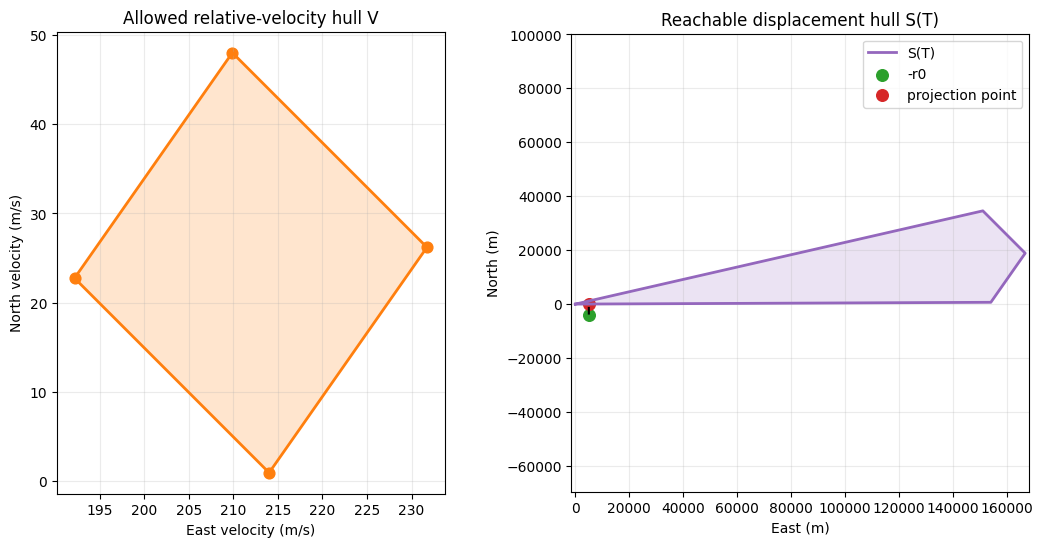

Geometric minimum distance from the projection: 3,917.74 m


In [3]:
straight_a_min_kt = max(straight_a_speed_kt - straight_speed_diff_kt, 0.0)
straight_a_max_kt = straight_a_speed_kt + straight_speed_diff_kt
straight_b_min_kt = max(straight_b_speed_kt - straight_speed_diff_kt, 0.0)
straight_b_max_kt = straight_b_speed_kt + straight_speed_diff_kt

straight_velocity_corners = np.asarray(
    [
        straight_dir_a * s_a_kt * KT_TO_MPS - straight_dir_b * s_b_kt * KT_TO_MPS
        for s_a_kt in (straight_a_min_kt, straight_a_max_kt)
        for s_b_kt in (straight_b_min_kt, straight_b_max_kt)
    ],
    dtype=np.float64,
)
straight_v_hull = _small_convex_hull(straight_velocity_corners)
straight_s_hull = compute_relative_velocity_hull(
    a_heading=straight_a_heading,
    a_speed_kt=straight_a_speed_kt,
    b_heading=straight_b_heading,
    b_speed_kt=straight_b_speed_kt,
    speed_diff_kt=straight_speed_diff_kt,
    projection_time_s=straight_projection_time_s,
)
straight_projection_point, _ = _closest_point_on_convex_polygon(
    np.asarray(straight_target, dtype=np.float64), np.asarray(straight_s_hull, dtype=np.float64)
)
straight_geometric_min_distance_m = float(np.linalg.norm(straight_r0 + straight_projection_point))

fig, (ax_v, ax_s) = plt.subplots(1, 2, figsize=(13, 6))
straight_v_hull_closed = close_polygon(straight_v_hull)
ax_v.scatter(straight_velocity_corners[:, 0], straight_velocity_corners[:, 1], c="tab:orange", s=60)
ax_v.plot(straight_v_hull_closed[:, 0], straight_v_hull_closed[:, 1], color="tab:orange", lw=2)
ax_v.fill(straight_v_hull_closed[:, 0], straight_v_hull_closed[:, 1], color="tab:orange", alpha=0.2)
style_axes(ax_v, "Allowed relative-velocity hull V", "East velocity (m/s)", "North velocity (m/s)")

straight_s_hull_closed = close_polygon(straight_s_hull)
ax_s.plot(straight_s_hull_closed[:, 0], straight_s_hull_closed[:, 1], color="tab:purple", lw=2, label="S(T)")
ax_s.fill(straight_s_hull_closed[:, 0], straight_s_hull_closed[:, 1], color="tab:purple", alpha=0.18)
ax_s.scatter([straight_target[0]], [straight_target[1]], c="tab:green", s=70, label="-r0")
ax_s.scatter(
    [straight_projection_point[0]], [straight_projection_point[1]], c="tab:red", s=70, label="projection point"
)
ax_s.plot(
    [straight_target[0], straight_projection_point[0]],
    [straight_target[1], straight_projection_point[1]],
    "k--",
    lw=1.5,
)
set_square_limits(
    ax_s, np.vstack([straight_s_hull, straight_target[None, :], straight_projection_point[None, :]]), 1_500.0
)
style_axes(ax_s, "Reachable displacement hull S(T)")
ax_s.legend(loc="best")
plt.show()

print(f"Geometric minimum distance from the projection: {straight_geometric_min_distance_m:,.2f} m")

**Figure interpretation.**

- Left panel: the four speed-corner combinations generate the feasible
  relative-velocity hull `V`.
- Right panel: the full-horizon reachable displacement hull `S(T)` obtained from `V`.
- The red projection point is the closest feasible displacement to `-r0`; the dashed
  segment therefore represents the exact minimum-distance construction for the
  straight-heading model.


### Public API check

The manual construction above is only for exposition. The public straight solver should
return the same minimum distance and closest time.


In [4]:
straight_is_separated, straight_min_distance_m, straight_closest_time_s = catch_up_projection_interval(
    a_lat=straight_a_lat,
    a_lon=straight_a_lon,
    a_heading=straight_a_heading,
    a_speed_kt=straight_a_speed_kt,
    b_lat=straight_b_lat,
    b_lon=straight_b_lon,
    b_heading=straight_b_heading,
    b_speed_kt=straight_b_speed_kt,
    separation_threshold_m=straight_separation_threshold_m,
    speed_diff_kt=straight_speed_diff_kt,
    projection_time_s=straight_projection_time_s,
)

print(f"is_separated: {straight_is_separated}")
print(f"min_distance_m: {straight_min_distance_m:,.2f} m")
print(f"closest_time_s: {straight_closest_time_s:,.2f} s")
print(f"diff_vs_manual_projection: {abs(straight_min_distance_m - straight_geometric_min_distance_m):.6e} m")
assert abs(straight_min_distance_m - straight_geometric_min_distance_m) < 1e-6

is_separated: False
min_distance_m: 3,917.74 m
closest_time_s: 23.33 s
diff_vs_manual_projection: 0.000000e+00 m


### Straight-heading takeaway

For the fixed-heading model, `catch_up_projection_interval` is exact within the stated
assumptions.

Inputs that matter in this model are:

- initial relative position
- both headings
- nominal speeds and symmetric speed uncertainty
- projection horizon

Geometrically, the method builds `V`, builds `S(T)`, projects `-r0`, and recovers the
closest time from that projection.


## Part II — Turn-aware certified method

Assume each aircraft either flies straight or performs at most one fixed-rate turn from
its current heading to a target heading, then continues straight. Speed uncertainty is
still modeled as one constant speed per aircraft over the horizon.

This walkthrough follows the current implementation rather than the earlier
chord/sagitta construction.

At a fixed time `t`, the reachable geometry is still a small exact convex hull. Over
continuous time, the solver uses interval certificates rather than a closed-form global
minimum.

If both aircraft are effectively straight in the sense used by the implementation
(current heading equals target heading, and turn rate is effectively zero), then
`catch_up_projection_interval_with_turns` delegates directly to
`catch_up_projection_interval`.


### Turn-aware method in one algorithm

For the turn-aware solver, the implementation logic is:

1. fix each aircraft's heading profile from `(heading0, target_heading, turn_rate_deg_sec)`
2. at any chosen time `t`, build the exact fixed-time hull `R(t)` from the four speed
   corners
3. compute `d(t) = dist(0, R(t))` exactly by convex projection
4. certify time intervals using endpoint samples and an interval-local Lipschitz bound
5. accept an interval as safe when its lower bound stays above the separation threshold
6. otherwise split the interval and repeat until the minimum interval length is reached

The extra work relative to the straight case is entirely in step 4: time is no longer
absorbed into one closed-form displacement hull.


### Turn-aware reduction

For one aircraft with fixed turn profile and one constant speed `s`, the displacement at
time `t` has the form `s b(t)`, where `b(t)` is the unit-speed turn basis.

For two aircraft, the fixed-time relative set is therefore
`R(t) = r0 + {s_A b_A(t) - s_B b_B(t)}` with `s_A` and `s_B` taken from their speed
intervals. At any fixed time this is just a small convex hull generated by the speed
corners.

Define `d(t) = dist(0, R(t))`. Then:

- `d(t)` is exact at each chosen time
- the remaining task is to certify the minimum of `d(t)` over continuous time


### Scenario and one-aircraft turn basis

The first object is the unit-speed turn basis `b_A(t)` for aircraft A.

For a fixed constant speed `s`, the displacement at time `t` is `s b_A(t)`. This
affine-in-speed structure is what keeps the fixed-time reachable set small.


In [ ]:
class TurnScenario(TypedDict):
    title: str
    description: str
    a_lat: float
    a_lon: float
    a_heading0_deg: float
    a_target_heading_deg: float
    a_speed_kt: float
    a_turn_rate_deg_sec: float
    b_east_m: float
    b_north_m: float
    b_heading0_deg: float
    b_target_heading_deg: float
    b_speed_kt: float
    b_turn_rate_deg_sec: float
    speed_diff_kt: float
    separation_threshold_m: float
    projection_time_s: float


TURN_SCENARIO: TurnScenario = {
    "title": "Single-turn dodge",
    "description": "Curated demo scenario: A turns, B stays straight, and the pair stays just above threshold.",
    "a_lat": 51.0,
    "a_lon": -1.0,
    "a_heading0_deg": 0.0,
    "a_target_heading_deg": 270.0,
    "a_speed_kt": 340.0,
    "a_turn_rate_deg_sec": 1.5,
    "b_east_m": -12_000.0,
    "b_north_m": -4_000.0,
    "b_heading0_deg": 90.0,
    "b_target_heading_deg": 90.0,
    "b_speed_kt": 340.0,
    "b_turn_rate_deg_sec": 0.0,
    "speed_diff_kt": 15.0,
    "separation_threshold_m": 5.0 * NMI_TO_M,
    "projection_time_s": 900.0,
}

turn_a_lat = TURN_SCENARIO["a_lat"]
turn_a_lon = TURN_SCENARIO["a_lon"]
turn_a_heading0_deg = TURN_SCENARIO["a_heading0_deg"]
turn_a_target_heading_deg = TURN_SCENARIO["a_target_heading_deg"]
turn_a_speed_kt = TURN_SCENARIO["a_speed_kt"]
turn_a_turn_rate_deg_sec = TURN_SCENARIO["a_turn_rate_deg_sec"]
turn_b_heading0_deg = TURN_SCENARIO["b_heading0_deg"]
turn_b_target_heading_deg = TURN_SCENARIO["b_target_heading_deg"]
turn_b_speed_kt = TURN_SCENARIO["b_speed_kt"]
turn_b_turn_rate_deg_sec = TURN_SCENARIO["b_turn_rate_deg_sec"]
turn_speed_diff_kt = TURN_SCENARIO["speed_diff_kt"]
turn_followup_buffer_kt = turn_speed_diff_kt
turn_separation_threshold_m = TURN_SCENARIO["separation_threshold_m"]
turn_projection_time_s = TURN_SCENARIO["projection_time_s"]

turn_b_lat, turn_b_lon = local_xy_to_latlon(
    TURN_SCENARIO["b_east_m"], TURN_SCENARIO["b_north_m"], turn_a_lat, turn_a_lon
)
turn_a_xy0 = np.array([0.0, 0.0])
turn_b_xy0 = latlon_to_local_xy(turn_b_lat, turn_b_lon, ref_lat=turn_a_lat, ref_lon=turn_a_lon)
turn_rel_pos0 = turn_a_xy0 - turn_b_xy0

turn_a_nom_speed_mps = turn_a_speed_kt * KT_TO_MPS
turn_b_nom_speed_mps = turn_b_speed_kt * KT_TO_MPS
turn_a_min_speed_mps, turn_a_max_speed_mps = speed_bounds_mps(turn_a_speed_kt, turn_speed_diff_kt)
turn_b_min_speed_mps, turn_b_max_speed_mps = speed_bounds_mps(turn_b_speed_kt, turn_speed_diff_kt)
turn_global_lipschitz_mps = turn_a_max_speed_mps + turn_b_max_speed_mps
turn_a_turn_duration_s = turn_duration_s(turn_a_heading0_deg, turn_a_target_heading_deg, turn_a_turn_rate_deg_sec)
turn_focus_time_s = 35.0

print(TURN_SCENARIO["title"])
print(TURN_SCENARIO["description"])
print(
    f"A: {turn_a_heading0_deg:.0f}->{turn_a_target_heading_deg:.0f} deg @ "
    f"{turn_a_turn_rate_deg_sec:.1f} deg/s, {turn_a_speed_kt:.0f} kt"
)
print(f"B: {turn_b_heading0_deg:.0f} deg straight @ {turn_b_speed_kt:.0f} kt")
print(f"Speed uncertainty: +/-{turn_speed_diff_kt:.0f} kt")

turn_basis_times_s = np.linspace(0.0, 120.0, 241)
turn_a_basis_xy = np.array(
    [
        _turn_displacement_basis(turn_a_heading0_deg, turn_a_target_heading_deg, turn_a_turn_rate_deg_sec, float(t_s))
        for t_s in turn_basis_times_s
    ]
)
turn_a_turn_end_basis = _turn_displacement_basis(
    turn_a_heading0_deg, turn_a_target_heading_deg, turn_a_turn_rate_deg_sec, turn_a_turn_duration_s
)
turn_a_focus_basis = _turn_displacement_basis(
    turn_a_heading0_deg, turn_a_target_heading_deg, turn_a_turn_rate_deg_sec, turn_focus_time_s
)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(turn_a_basis_xy[:, 0], turn_a_basis_xy[:, 1], color="tab:blue", lw=2.4, label="b_A(t)")
ax.scatter([0.0], [0.0], c="tab:gray", s=55)
ax.scatter([turn_a_turn_end_basis[0]], [turn_a_turn_end_basis[1]], c="tab:orange", s=70, label="turn end")
ax.scatter([turn_a_focus_basis[0]], [turn_a_focus_basis[1]], c="tab:red", s=70, label="focus time")
style_axes(ax, "A unit-speed turn basis b_A(t)", "East component of b_A(t) (s)", "North component of b_A(t) (s)")
ax.legend(loc="best")
plt.show()

**Figure interpretation.**

- The curve is the unit-speed turn basis `b_A(t)`.
- Multiplying this curve by a constant speed gives aircraft A's displacement at the
  same time.
- The orange point marks the end of the active turn. Beyond that point the basis moves
  along a straight ray, because the aircraft has reached its target heading.
- The red point is the basis value at the focus time used later for the fixed-time hull.


### Fixed-time relative hull

Choose one time `t*` near the closest approach. The next figure shows:

- nominal trajectories in absolute coordinates
- the exact fixed-time relative hull `R(t*)` in relative coordinates

The right-hand panel is the object used by the fixed-time helper: the minimum
fixed-time separation is the distance from the origin to `R(t*)`.


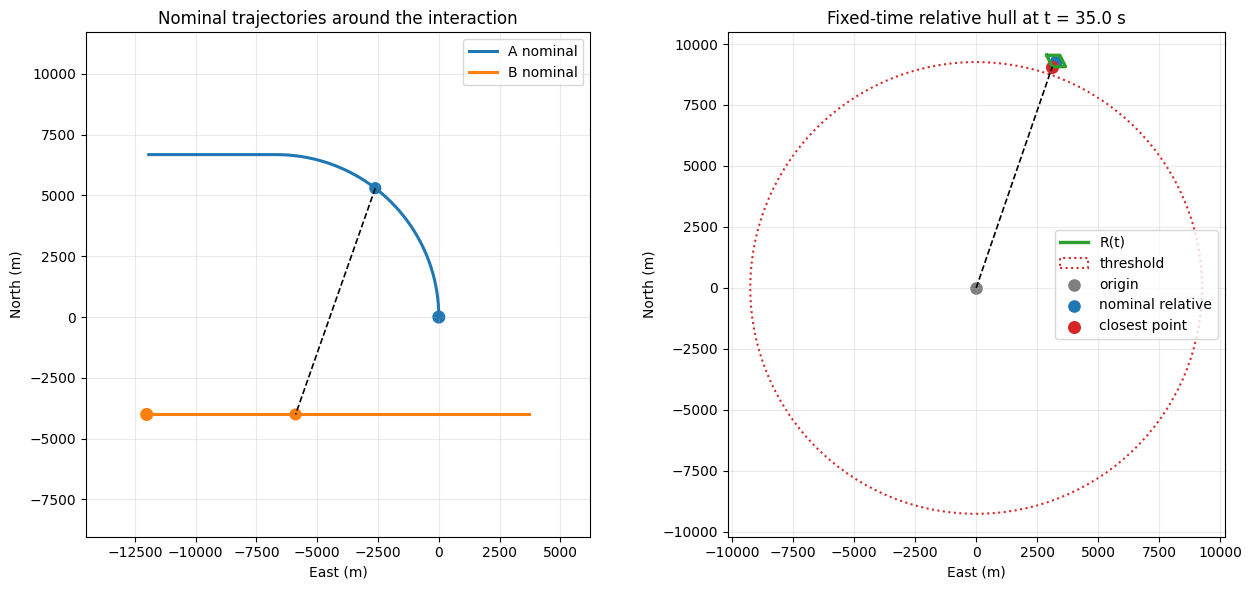

In [6]:
turn_plot_times_s = np.linspace(0.0, 90.0, 181)
turn_a_nominal_traj_xy = sample_trajectory_xy(
    turn_a_xy0,
    turn_a_heading0_deg,
    turn_a_target_heading_deg,
    turn_a_nom_speed_mps,
    turn_a_turn_rate_deg_sec,
    turn_plot_times_s,
)
turn_b_nominal_traj_xy = sample_trajectory_xy(
    turn_b_xy0,
    turn_b_heading0_deg,
    turn_b_target_heading_deg,
    turn_b_nom_speed_mps,
    turn_b_turn_rate_deg_sec,
    turn_plot_times_s,
)
turn_a_focus_nominal_xy = trajectory_point_xy(
    turn_a_xy0,
    turn_a_heading0_deg,
    turn_a_target_heading_deg,
    turn_a_nom_speed_mps,
    turn_a_turn_rate_deg_sec,
    turn_focus_time_s,
)
turn_b_focus_nominal_xy = trajectory_point_xy(
    turn_b_xy0,
    turn_b_heading0_deg,
    turn_b_target_heading_deg,
    turn_b_nom_speed_mps,
    turn_b_turn_rate_deg_sec,
    turn_focus_time_s,
)
turn_rel_hull = _relative_position_hull_at_time(
    rel_pos0=turn_rel_pos0,
    a_heading0_deg=turn_a_heading0_deg,
    a_target_heading_deg=turn_a_target_heading_deg,
    a_turn_rate_deg_sec=turn_a_turn_rate_deg_sec,
    a_min_speed_mps=turn_a_min_speed_mps,
    a_max_speed_mps=turn_a_max_speed_mps,
    b_heading0_deg=turn_b_heading0_deg,
    b_target_heading_deg=turn_b_target_heading_deg,
    b_turn_rate_deg_sec=turn_b_turn_rate_deg_sec,
    b_min_speed_mps=turn_b_min_speed_mps,
    b_max_speed_mps=turn_b_max_speed_mps,
    t_s=turn_focus_time_s,
)
turn_relative_nominal_focus_xy = turn_a_focus_nominal_xy - turn_b_focus_nominal_xy
turn_relative_projection_xy, _ = _closest_point_on_convex_polygon(
    np.zeros(2, dtype=np.float64), np.asarray(turn_rel_hull, dtype=np.float64)
)

fig, (ax_xy, ax_rel) = plt.subplots(1, 2, figsize=(13, 6))
ax_xy.scatter([turn_a_xy0[0], turn_b_xy0[0]], [turn_a_xy0[1], turn_b_xy0[1]], c=["tab:blue", "tab:orange"], s=70)
ax_xy.plot(turn_a_nominal_traj_xy[:, 0], turn_a_nominal_traj_xy[:, 1], color="tab:blue", lw=2.2, label="A nominal")
ax_xy.plot(turn_b_nominal_traj_xy[:, 0], turn_b_nominal_traj_xy[:, 1], color="tab:orange", lw=2.2, label="B nominal")
ax_xy.scatter(
    [turn_a_focus_nominal_xy[0], turn_b_focus_nominal_xy[0]],
    [turn_a_focus_nominal_xy[1], turn_b_focus_nominal_xy[1]],
    c=["tab:blue", "tab:orange"],
    s=60,
)
ax_xy.plot(
    [turn_a_focus_nominal_xy[0], turn_b_focus_nominal_xy[0]],
    [turn_a_focus_nominal_xy[1], turn_b_focus_nominal_xy[1]],
    "k--",
    lw=1.2,
)
set_square_limits(ax_xy, np.vstack([turn_a_nominal_traj_xy, turn_b_nominal_traj_xy]), 2_500.0)
style_axes(ax_xy, "Nominal trajectories around the interaction")
ax_xy.legend(loc="best")

turn_rel_hull_closed = close_polygon(turn_rel_hull)
ax_rel.plot(turn_rel_hull_closed[:, 0], turn_rel_hull_closed[:, 1], color="tab:green", lw=2.4, label="R(t)")
ax_rel.fill(turn_rel_hull_closed[:, 0], turn_rel_hull_closed[:, 1], color="tab:green", alpha=0.18)
ax_rel.add_patch(
    Circle((0.0, 0.0), turn_separation_threshold_m, fill=False, ls=":", lw=1.5, color="tab:red", label="threshold")
)
ax_rel.scatter([0.0], [0.0], c="tab:gray", s=65, label="origin")
ax_rel.scatter(
    [turn_relative_nominal_focus_xy[0]],
    [turn_relative_nominal_focus_xy[1]],
    c="tab:blue",
    s=65,
    label="nominal relative",
)
ax_rel.scatter(
    [turn_relative_projection_xy[0]], [turn_relative_projection_xy[1]], c="tab:red", s=70, label="closest point"
)
ax_rel.plot([0.0, turn_relative_projection_xy[0]], [0.0, turn_relative_projection_xy[1]], "k--", lw=1.2)
style_axes(ax_rel, f"Fixed-time relative hull at t = {turn_focus_time_s:.1f} s")
ax_rel.legend(loc="best")
plt.tight_layout()
plt.show()

**Figure interpretation.**

- Left panel: nominal trajectories are shown only to locate the interaction in absolute
  space.
- Right panel: `R(t*)` is the exact fixed-time relative hull produced by the min/max
  speed combinations at the chosen time.
- The origin is the protected centre in relative coordinates. The dashed segment to the
  red point is the shortest vector from the origin to `R(t*)`, so its length is the
  exact fixed-time worst-case separation.


### Fixed-time projection check

The next cell computes the same fixed-time quantity in two ways:

- direct projection of the origin onto the plotted hull
- `_min_distance_to_relative_hull_at_time(...)`

Agreement here confirms the fixed-time geometry shown in the figure.


In [7]:
turn_fixed_time_distance_from_projection_m = float(np.linalg.norm(turn_relative_projection_xy))
turn_fixed_time_distance_from_helper_m = _min_distance_to_relative_hull_at_time(
    rel_pos0=turn_rel_pos0,
    a_heading0_deg=turn_a_heading0_deg,
    a_target_heading_deg=turn_a_target_heading_deg,
    a_turn_rate_deg_sec=turn_a_turn_rate_deg_sec,
    a_min_speed_mps=turn_a_min_speed_mps,
    a_max_speed_mps=turn_a_max_speed_mps,
    b_heading0_deg=turn_b_heading0_deg,
    b_target_heading_deg=turn_b_target_heading_deg,
    b_turn_rate_deg_sec=turn_b_turn_rate_deg_sec,
    b_min_speed_mps=turn_b_min_speed_mps,
    b_max_speed_mps=turn_b_max_speed_mps,
    t_s=turn_focus_time_s,
)
print(f"focus time: {turn_focus_time_s:.1f} s")
print(f"fixed-time worst-case distance from projection: {turn_fixed_time_distance_from_projection_m:,.2f} m")
print(f"fixed-time worst-case distance from helper: {turn_fixed_time_distance_from_helper_m:,.2f} m")
assert abs(turn_fixed_time_distance_from_projection_m - turn_fixed_time_distance_from_helper_m) < 1e-9

focus time: 35.0 s
fixed-time worst-case distance from projection: 9,593.62 m
fixed-time worst-case distance from helper: 9,593.62 m


### Interval certification in time

The remaining problem is continuous time. The solver evaluates exact fixed-time
distances only at selected times and uses a Lipschitz bound to certify whole
intervals.

If `d(t)` is bounded by an interval-local Lipschitz constant `L_I` on `I = [t0, t1]`,
then the minimum of `d(t)` on that interval is bounded below by
`(d(t0) + d(t1) - L_I (t1 - t0)) / 2`.

The example below compares:

- one interval that is too wide to certify
- one narrower interval that is certified safe


In [ ]:
turn_interval_times_s = np.linspace(30.0, 40.0, 401)
turn_interval_distances_m = np.array(
    [
        _min_distance_to_relative_hull_at_time(
            rel_pos0=turn_rel_pos0,
            a_heading0_deg=turn_a_heading0_deg,
            a_target_heading_deg=turn_a_target_heading_deg,
            a_turn_rate_deg_sec=turn_a_turn_rate_deg_sec,
            a_min_speed_mps=turn_a_min_speed_mps,
            a_max_speed_mps=turn_a_max_speed_mps,
            b_heading0_deg=turn_b_heading0_deg,
            b_target_heading_deg=turn_b_target_heading_deg,
            b_turn_rate_deg_sec=turn_b_turn_rate_deg_sec,
            b_min_speed_mps=turn_b_min_speed_mps,
            b_max_speed_mps=turn_b_max_speed_mps,
            t_s=float(t_s),
        )
        for t_s in turn_interval_times_s
    ]
)


def certificate(t0_s: float, t1_s: float) -> tuple[float, float, float, float]:
    d0_m = _min_distance_to_relative_hull_at_time(
        rel_pos0=turn_rel_pos0,
        a_heading0_deg=turn_a_heading0_deg,
        a_target_heading_deg=turn_a_target_heading_deg,
        a_turn_rate_deg_sec=turn_a_turn_rate_deg_sec,
        a_min_speed_mps=turn_a_min_speed_mps,
        a_max_speed_mps=turn_a_max_speed_mps,
        b_heading0_deg=turn_b_heading0_deg,
        b_target_heading_deg=turn_b_target_heading_deg,
        b_turn_rate_deg_sec=turn_b_turn_rate_deg_sec,
        b_min_speed_mps=turn_b_min_speed_mps,
        b_max_speed_mps=turn_b_max_speed_mps,
        t_s=t0_s,
    )
    d1_m = _min_distance_to_relative_hull_at_time(
        rel_pos0=turn_rel_pos0,
        a_heading0_deg=turn_a_heading0_deg,
        a_target_heading_deg=turn_a_target_heading_deg,
        a_turn_rate_deg_sec=turn_a_turn_rate_deg_sec,
        a_min_speed_mps=turn_a_min_speed_mps,
        a_max_speed_mps=turn_a_max_speed_mps,
        b_heading0_deg=turn_b_heading0_deg,
        b_target_heading_deg=turn_b_target_heading_deg,
        b_turn_rate_deg_sec=turn_b_turn_rate_deg_sec,
        b_min_speed_mps=turn_b_min_speed_mps,
        b_max_speed_mps=turn_b_max_speed_mps,
        t_s=t1_s,
    )
    L = _interval_local_lipschitz_mps(
        a_heading0_deg=turn_a_heading0_deg,
        a_target_heading_deg=turn_a_target_heading_deg,
        a_turn_rate_deg_sec=turn_a_turn_rate_deg_sec,
        a_min_speed_mps=turn_a_min_speed_mps,
        a_max_speed_mps=turn_a_max_speed_mps,
        b_heading0_deg=turn_b_heading0_deg,
        b_target_heading_deg=turn_b_target_heading_deg,
        b_turn_rate_deg_sec=turn_b_turn_rate_deg_sec,
        b_min_speed_mps=turn_b_min_speed_mps,
        b_max_speed_mps=turn_b_max_speed_mps,
        t0_s=t0_s,
        t1_s=t1_s,
        global_lipschitz_mps=turn_global_lipschitz_mps,
    )
    lb = _interval_distance_lower_bound(d0_m, d1_m, L, t1_s - t0_s)
    return d0_m, d1_m, L, lb


wide = (30.0, 40.0)
narrow = (35.0, 36.0)
wide_d0, wide_d1, wide_L, wide_lb = certificate(*wide)
narrow_d0, narrow_d1, narrow_L, narrow_lb = certificate(*narrow)
wide_certified = wide_lb >= turn_separation_threshold_m
narrow_certified = narrow_lb >= turn_separation_threshold_m
print("interval        d(t0) m   d(t1) m   L_I m/s   lower bound m   certified?")
print(f"[30, 40] s   {wide_d0:8.1f} {wide_d1:8.1f} {wide_L:9.2f} {wide_lb:14.1f}   {wide_certified}")
print(f"[35, 36] s   {narrow_d0:8.1f} {narrow_d1:8.1f} {narrow_L:9.2f} {narrow_lb:14.1f}   {narrow_certified}")

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(
    turn_interval_times_s,
    turn_interval_distances_m / NMI_TO_M,
    color="tab:green",
    lw=2.5,
    label="exact fixed-time envelope distance d(t)",
)
ax.axhline(turn_separation_threshold_m / NMI_TO_M, color="tab:red", ls=":", lw=1.5, label="threshold")
ax.hlines(wide_lb / NMI_TO_M, *wide, color="tab:orange", lw=3, label="lower bound on [30, 40] s")
ax.hlines(narrow_lb / NMI_TO_M, *narrow, color="tab:blue", lw=3, label="lower bound on [35, 36] s")
ax.set_title("Interval-local certification around the closest approach")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Distance (NMI)")
ax.grid(True, alpha=0.25)
ax.legend(loc="best")
plt.show()
assert wide_lb < turn_separation_threshold_m
assert narrow_lb >= turn_separation_threshold_m

**Figure interpretation.**

- The green curve is the exact fixed-time envelope distance `d(t)`, sampled densely here
  for visual reference.
- The horizontal orange and blue segments are interval lower bounds produced from the
  endpoint distances and the interval-local Lipschitz constant.
- The wide interval is too loose to certify; the narrower interval clears the threshold.
  The production solver repeats this logic adaptively until each interval is either
  certified or split further.


### How the production certifier uses this bound

The implementation applies the interval certificate recursively over the projection
horizon.

1. Start with the whole interval `[0, T]`.
2. Evaluate the exact fixed-time distance at the interval endpoints.
3. Compute the interval-local Lipschitz constant `L_I`.
4. Form the lower bound `(d(t0) + d(t1) - L_I (t1 - t0)) / 2`.
5. If that lower bound is above the threshold, declare the whole interval safe.
6. Otherwise split the interval and apply the same test to the subintervals.

This is why the turn-aware method is exact in speed at fixed times but conservative in
continuous time.


### `turn_speed_schedule_uncertainty_kt`

This optional parameter is a robustness margin for possible speed variation during the
active turn. It is not part of the base constant-speed turn model and it defaults to
zero.

A practical first setting is `turn_speed_schedule_uncertainty_kt = speed_diff_kt`,
which asks for a stronger buffered claim.


### Public API and optional robustness buffer

The final turn-aware cell calls `catch_up_projection_interval_with_turns` directly. It
also shows how the optional robustness buffer can change the boolean result when the
same geometry is checked under a stricter effective threshold.

For the turn-aware API, the boolean separation result is the guaranteed quantity. The
reported minimum distance and closest time are diagnostic summaries of the certified
search.

When neither aircraft actually turns, this API does not run the turn-aware certifier at
all; it delegates to `catch_up_projection_interval`.


In [9]:
turn_api_default = catch_up_projection_interval_with_turns(
    a_lat=turn_a_lat,
    a_lon=turn_a_lon,
    a_heading0_deg=turn_a_heading0_deg,
    a_target_heading_deg=turn_a_target_heading_deg,
    a_speed_kt=turn_a_speed_kt,
    a_turn_rate_deg_sec=turn_a_turn_rate_deg_sec,
    b_lat=turn_b_lat,
    b_lon=turn_b_lon,
    b_heading0_deg=turn_b_heading0_deg,
    b_target_heading_deg=turn_b_target_heading_deg,
    b_speed_kt=turn_b_speed_kt,
    b_turn_rate_deg_sec=turn_b_turn_rate_deg_sec,
    separation_threshold_m=turn_separation_threshold_m,
    speed_diff_kt=turn_speed_diff_kt,
    projection_time_s=turn_projection_time_s,
)
turn_api_buffered = catch_up_projection_interval_with_turns(
    a_lat=turn_a_lat,
    a_lon=turn_a_lon,
    a_heading0_deg=turn_a_heading0_deg,
    a_target_heading_deg=turn_a_target_heading_deg,
    a_speed_kt=turn_a_speed_kt,
    a_turn_rate_deg_sec=turn_a_turn_rate_deg_sec,
    b_lat=turn_b_lat,
    b_lon=turn_b_lon,
    b_heading0_deg=turn_b_heading0_deg,
    b_target_heading_deg=turn_b_target_heading_deg,
    b_speed_kt=turn_b_speed_kt,
    b_turn_rate_deg_sec=turn_b_turn_rate_deg_sec,
    separation_threshold_m=turn_separation_threshold_m,
    speed_diff_kt=turn_speed_diff_kt,
    projection_time_s=turn_projection_time_s,
    turn_speed_schedule_uncertainty_kt=turn_followup_buffer_kt,
)

print("default result:")
print(f"  is_separated: {turn_api_default[0]}")
print(f"  min_distance_m: {turn_api_default[1]:,.2f} m")
print(f"  closest_time_s: {turn_api_default[2]:,.2f} s")
print()
print(f"buffered result with turn_speed_schedule_uncertainty_kt = {turn_followup_buffer_kt:.1f} kt:")
print(f"  is_separated: {turn_api_buffered[0]}")
print(f"  min_distance_m: {turn_api_buffered[1]:,.2f} m")
print(f"  closest_time_s: {turn_api_buffered[2]:,.2f} s")
print()
print("The buffered result is a stronger robustness question, not a contradiction.")

assert turn_api_default[0] is True
assert abs(turn_api_default[2] - turn_focus_time_s) < 1.0
assert turn_api_buffered[0] is False

default result:
  is_separated: True
  min_distance_m: 9,592.71 m
  closest_time_s: 35.16 s

buffered result with turn_speed_schedule_uncertainty_kt = 15.0 kt:
  is_separated: False
  min_distance_m: 0.00 m
  closest_time_s: 450.00 s

The buffered result is a stronger robustness question, not a contradiction.


## Closing summary

- `catch_up_projection_interval` is exact for the fixed-heading model.
- `catch_up_projection_interval_with_turns` is exact in bounded speed at fixed time and
  conservative over continuous time.
- The notebook uses private helpers to expose intermediate geometry.
- Production code should call `catch_up_projection_interval` or
  `catch_up_projection_interval_with_turns`.

In geometric terms:

- straight flight reduces to one projection onto a reachable displacement hull
- turning flight reduces to exact fixed-time hulls plus interval certification in time
